In [69]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [70]:
# Estructura base DCEL con métodos mágicos para visualización
class Vertex:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.incident_edge = None  # Semi-arista incidente

    def __repr__(self):
        return f"Vertex({self.x}, {self.y})"

    def __str__(self):
        return f"V({self.x}, {self.y})"


class HalfEdge:
    def __init__(self, origin):
        self.origin = origin
        self.twin = None
        self.next = None
        self.prev = None
        self.incident_face = None  # Cara a la izquierda

    def __repr__(self):
        twin_info = f" → Twin({self.twin.origin})" if self.twin else " → No Twin"
        return f"HalfEdge({self.origin}){twin_info}"

    def __str__(self):
        return f"E({self.origin} → {self.twin.origin if self.twin else 'None'})"


class Face:
    def __init__(self):
        self.outer_component = None  # Semi-arista de la frontera exterior
        self.inner_components = []  # Posibles islas interiores

    def __repr__(self):
        return f"Face(Outer: {self.outer_component})"

    def __str__(self):
        return f"F(Outer: {self.outer_component})"


class DCEL:
    def __init__(self):
        self.vertices = []
        self.edges = []
        self.faces = []

    def add_vertex(self, x, y):
        v = Vertex(x, y)
        self.vertices.append(v)
        return v

    def add_edge(self, v1, v2):
        e1 = HalfEdge(v1)
        e2 = HalfEdge(v2)
        e1.twin = e2
        e2.twin = e1
        self.edges.append(e1)
        self.edges.append(e2)
        return e1, e2

    def __repr__(self):
        return f"DCEL(Vertices: {len(self.vertices)}, Edges: {len(self.edges)}, Faces: {len(self.faces)})"

    def __str__(self):
        vertices_str = ", ".join(str(v) for v in self.vertices)
        edges_str = ", ".join(str(e) for e in self.edges)
        faces_str = ", ".join(str(f) for f in self.faces)
        return f"DCEL:\n  Vertices: {vertices_str}\n  Edges: {edges_str}\n  Faces: {faces_str}"




def find_common_edges(dcel1, dcel2):
    """
    Encuentra semi-aristas comunes entre dos DCELs comparando por coordenadas.
    """
    common_edges = []
    
    for edge1 in dcel1.edges:
        for edge2 in dcel2.edges:
            if ((edge1.origin.x, edge1.origin.y) == (edge2.twin.origin.x, edge2.twin.origin.y) and 
                (edge1.twin.origin.x, edge1.twin.origin.y) == (edge2.origin.x, edge2.origin.y)):
                common_edges.append((edge1, edge2))

    print(f"Aristas en común: {len(common_edges)}")
    return common_edges

# def get_face_vertices(face):
#     """
#     Dado un objeto Face, retorna los vértices en orden a partir de su semi-arista exterior.
#     """
#     vertices = []
#     start = face.outer_component
#     edge = start

#     while True:
#         vertices.append(edge.origin)
#         edge = edge.next
#         if edge == start or edge is None:
#             break

#     return vertices


# def insertar_diagonales_en_dcel(dcel, diagonales):
#     """
#     Inserta cada diagonal (v1, v2) como par de semi-aristas conectadas en la DCEL.
#     Las inserciones no actualizan completamente la estructura de caras.
#     """
#     for v1, v2 in diagonales:
#         # Crear nueva arista diagonal con twin
#         e1 = HalfEdge(v1)
#         e2 = HalfEdge(v2)
#         e1.twin = e2
#         e2.twin = e1

#         # Añadirlas a la DCEL
#         dcel.edges.extend([e1, e2])

#         print(f"🔧 Insertando diagonal entre {v1} y {v2} como aristas:")
#         print(f"   → {e1}")
#         print(f"   → {e2}")




def visualize_multiple_dcel(dcel_list):
    """
    Función para visualizar múltiples DCELs en una sola imagen.
    
    :param dcel_list: Lista de objetos DCEL a visualizar.
    """
    G = nx.DiGraph()  # Grafo dirigido para representar todas las DCELs
    vertex_ids = {}  # Diccionario de identificadores de vértices globales

    # Crear identificadores únicos de vértices por DCEL
    for dcel_idx, dcel in enumerate(dcel_list):
        for idx, v in enumerate(dcel.vertices):
            vertex_ids[v] = f"V{dcel_idx+1}_{idx+1}"

    # Crear posiciones de los vértices en formato compatible con NetworkX
    vertex_positions = {vertex_ids[v]: (v.x, v.y) for dcel in dcel_list for v in dcel.vertices}

    # Agregar nodos (vértices) al grafo
    for v_id in vertex_positions.keys():
        G.add_node(v_id, pos=vertex_positions[v_id])

    # Agregar semi-aristas al grafo
    edge_labels = {}
    for dcel in dcel_list:
        for edge in dcel.edges:
            if edge.next:  # Evita mostrar aristas sin conexión
                u, v = vertex_ids[edge.origin], vertex_ids[edge.next.origin]
                G.add_edge(u, v)
                edge_labels[(u, v)] = f"{u} → {v}"

    # Configurar la figura
    plt.figure(figsize=(8, 8))
    pos = vertex_positions

    # Dibujar nodos (vértices)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=8)

    # Dibujar etiquetas de las aristas
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=7)

    # Mostrar el gráfico
    plt.title("Visualización de Múltiples DCEL en una Sola Imagen")
    plt.show()
    
    
    
def obtener_caminos_cara(v1, v2, face):
    """
    Retorna dos caminos (listas de aristas) que conectan v1 y v2 recorriendo el ciclo en sentido .next.
    Se asegura que las aristas estén orientadas correctamente.
    """
    if not face or not face.outer_component:
        raise ValueError("❗ La cara no tiene frontera.")

    ciclo = []
    start = face.outer_component
    edge = start

    while True:
        ciclo.append(edge)
        edge = edge.next
        if edge == start:
            break

    # Buscar primera arista cuya origin sea v1 o v2
    i1, i2 = -1, -1
    for i, e in enumerate(ciclo):
        if e.origin == v1 and i1 == -1:
            i1 = i
        elif e.origin == v2 and i2 == -1:
            i2 = i

    if i1 == -1 or i2 == -1:
        raise ValueError("❌ v1 o v2 no están en el ciclo de la cara.")

    # Dos caminos: desde v1→v2 y desde v2→v1
    def camino_desde_hasta(ciclo, desde, hasta):
        camino = []
        i = desde
        while i != hasta:
            camino.append(ciclo[i])
            i = (i + 1) % len(ciclo)
        return camino

    camino1 = camino_desde_hasta(ciclo, i1, i2)
    camino2 = camino_desde_hasta(ciclo, i2, i1)

    return camino1, camino2
    


def insertar_diagonal_y_actualizar_caras(dcel, v1, v2, face_original):
    """
    Inserta una diagonal entre v1 y v2 y divide la cara en dos nuevas caras.
    Reconstruye los ciclos desde cero para evitar errores de conectividad.
    """

    # 1. Crear la diagonal y sus twins
    e = HalfEdge(v1)
    e_twin = HalfEdge(v2)
    e.twin = e_twin
    e_twin.twin = e
    dcel.edges.extend([e, e_twin])

    # 2. Obtener los caminos entre los vértices
    camino1, camino2 = obtener_caminos_cara(v1, v2, face_original)

    # 3. Armar dos listas ordenadas de semi-aristas para las nuevas caras
    ciclo1 = [e] + camino1
    ciclo2 = [e_twin] + camino2

    # 4. Conectar next/prev en cada ciclo
    def conectar_ciclo(aristas):
        n = len(aristas)
        for i in range(n):
            aristas[i].next = aristas[(i + 1) % n]
            aristas[(i + 1) % n].prev = aristas[i]

    conectar_ciclo(ciclo1)
    conectar_ciclo(ciclo2)

    # 5. Crear dos nuevas caras
    f1 = Face()
    f2 = Face()
    dcel.faces.extend([f1, f2])

    for a in ciclo1:
        a.incident_face = f1
    for a in ciclo2:
        a.incident_face = f2

    f1.outer_component = e
    f2.outer_component = e_twin

    # 6. Eliminar la cara original (ya fue partida)
    if face_original in dcel.faces:
        dcel.faces.remove(face_original)

    return e, e_twin, f1, f2

def encontrar_cara_comun(dcel, v1, v2):
    """
    Busca una cara que contenga a v1 y v2 recorriendo sus bordes.
    Devuelve la primera cara en la que ambos vértices están conectados por un ciclo.
    """
    for face in dcel.faces:
        if not face.outer_component:
            continue

        ciclo = []
        edge = face.outer_component
        start = edge
        while True:
            ciclo.append(edge.origin)
            edge = edge.next
            if edge == start or edge is None:
                break

        if v1 in ciclo and v2 in ciclo:
            print(f"✅ Cara encontrada para la diagonal entre {v1} y {v2}")
            return face

    print(f"⚠️ No se encontró cara común entre {v1} y {v2}")
    return None




In [71]:


# CÉLULA ACTUALIZADA: Cargar puntos desde archivo con limpieza de texto
def cargar_puntos(path="Polygon.txt"):
    with open(path, "r") as f:
        lines = f.readlines()
    
    puntos = []
    for line in lines:
        # Eliminar corchetes y espacios
        line = line.strip().replace("[", "").replace("]", "")
        if not line:
            continue
        x_str, y_str = line.split()
        puntos.append((float(x_str), float(y_str)))
    
    return puntos

# Probar la función
puntos = cargar_puntos()
print("Total de puntos:", len(puntos))
print("Primeros 3 puntos:", puntos[:3])


Total de puntos: 19
Primeros 3 puntos: [(9.0, 0.5), (8.0, 6.0), (7.0, -3.0)]


In [72]:
# CÉLULA 2: Crear DCEL simple a partir del polígono cerrado

def construir_dcel_simple(puntos):
    dcel = DCEL()
    n = len(puntos) - 1  # asumimos que el último es repetido

    # 1. Crear vértices
    vertices = [dcel.add_vertex(x, y) for x, y in puntos[:-1]]

    # 2. Crear semi-aristas y sus twins
    edges = []
    for i in range(n):
        v1 = vertices[i]
        v2 = vertices[(i + 1) % n]
        e1, e2 = dcel.add_edge(v1, v2)  # e1: v1 → v2; e2: twin
        edges.append(e1)
        dcel.edges.append(e2)  # twin también se guarda
        v1.incident_edge = e1  # puede ser útil para búsqueda
    print(f"🔧 Total de semi-aristas creadas: {len(dcel.edges)} (con twins)")

    # 3. Conectar next y prev de forma circular
    for i in range(n):
        e = edges[i]
        e.next = edges[(i + 1) % n]
        e.prev = edges[(i - 1) % n]

    # 4. Crear la cara exterior y asignar incident_face
    f = Face()
    dcel.faces.append(f)
    f.outer_component = edges[0]

    for i, e in enumerate(edges):
        e.incident_face = f
        print(f"✅ Arista {i}: {e} → next={e.next.origin}, prev={e.prev.origin}, face_id={id(e.incident_face)}")

    print(f"🧱 Cara creada con outer_component: {f.outer_component.origin} → {f.outer_component.twin.origin}")

    return dcel


In [73]:
dcel = construir_dcel_simple(puntos)

print("\n🧪 Verificando aristas con incident_face=None:")
for i, e in enumerate(dcel.edges):
    if e.incident_face is None:
        print(f"⚠️ Arista {i} sin incident_face: {e}")


🔧 Total de semi-aristas creadas: 54 (con twins)
✅ Arista 0: E(V(9.0, 0.5) → V(8.0, 6.0)) → next=V(8.0, 6.0), prev=V(10.0, -1.0), face_id=2304246187744
✅ Arista 1: E(V(8.0, 6.0) → V(7.0, -3.0)) → next=V(7.0, -3.0), prev=V(9.0, 0.5), face_id=2304246187744
✅ Arista 2: E(V(7.0, -3.0) → V(6.0, 3.0)) → next=V(6.0, 3.0), prev=V(8.0, 6.0), face_id=2304246187744
✅ Arista 3: E(V(6.0, 3.0) → V(4.0, -4.0)) → next=V(4.0, -4.0), prev=V(7.0, -3.0), face_id=2304246187744
✅ Arista 4: E(V(4.0, -4.0) → V(2.0, -3.0)) → next=V(2.0, -3.0), prev=V(6.0, 3.0), face_id=2304246187744
✅ Arista 5: E(V(2.0, -3.0) → V(3.0, 4.0)) → next=V(3.0, 4.0), prev=V(4.0, -4.0), face_id=2304246187744
✅ Arista 6: E(V(3.0, 4.0) → V(4.0, 2.5)) → next=V(4.0, 2.5), prev=V(2.0, -3.0), face_id=2304246187744
✅ Arista 7: E(V(4.0, 2.5) → V(5.0, 12.0)) → next=V(5.0, 12.0), prev=V(3.0, 4.0), face_id=2304246187744
✅ Arista 8: E(V(5.0, 12.0) → V(7.0, 8.5)) → next=V(7.0, 8.5), prev=V(4.0, 2.5), face_id=2304246187744
✅ Arista 9: E(V(7.0, 8.5) 

In [74]:
puntos = cargar_puntos()
dcel = construir_dcel_simple(puntos)

try:
    assert len(dcel.vertices) == len(puntos) - 1, f"❌ Número incorrecto de vértices: {len(dcel.vertices)}"
    assert len(dcel.edges) == 2 * (len(puntos) - 1), f"❌ Número incorrecto de aristas: {len(dcel.edges)}"
    assert dcel.faces[0].outer_component.origin == dcel.vertices[0], "❌ La cara exterior no comienza en el primer vértice"

    for i, e in enumerate(dcel.edges):
        if e.twin and e.twin.twin != e:
            raise AssertionError(f"❌ Twin inconsistente en arista {i}: {e}")
        if e.next and e.next.prev != e:
            raise AssertionError(f"❌ Next/Prev inconsistente en arista {i}: {e}")
    
    print("✅ Verificación DCEL simple construida: True")
except AssertionError as err:
    print(err)
    print("❌ Verificación DCEL simple construida: False")


🔧 Total de semi-aristas creadas: 54 (con twins)
✅ Arista 0: E(V(9.0, 0.5) → V(8.0, 6.0)) → next=V(8.0, 6.0), prev=V(10.0, -1.0), face_id=2304246716432
✅ Arista 1: E(V(8.0, 6.0) → V(7.0, -3.0)) → next=V(7.0, -3.0), prev=V(9.0, 0.5), face_id=2304246716432
✅ Arista 2: E(V(7.0, -3.0) → V(6.0, 3.0)) → next=V(6.0, 3.0), prev=V(8.0, 6.0), face_id=2304246716432
✅ Arista 3: E(V(6.0, 3.0) → V(4.0, -4.0)) → next=V(4.0, -4.0), prev=V(7.0, -3.0), face_id=2304246716432
✅ Arista 4: E(V(4.0, -4.0) → V(2.0, -3.0)) → next=V(2.0, -3.0), prev=V(6.0, 3.0), face_id=2304246716432
✅ Arista 5: E(V(2.0, -3.0) → V(3.0, 4.0)) → next=V(3.0, 4.0), prev=V(4.0, -4.0), face_id=2304246716432
✅ Arista 6: E(V(3.0, 4.0) → V(4.0, 2.5)) → next=V(4.0, 2.5), prev=V(2.0, -3.0), face_id=2304246716432
✅ Arista 7: E(V(4.0, 2.5) → V(5.0, 12.0)) → next=V(5.0, 12.0), prev=V(3.0, 4.0), face_id=2304246716432
✅ Arista 8: E(V(5.0, 12.0) → V(7.0, 8.5)) → next=V(7.0, 8.5), prev=V(4.0, 2.5), face_id=2304246716432
✅ Arista 9: E(V(7.0, 8.5) 

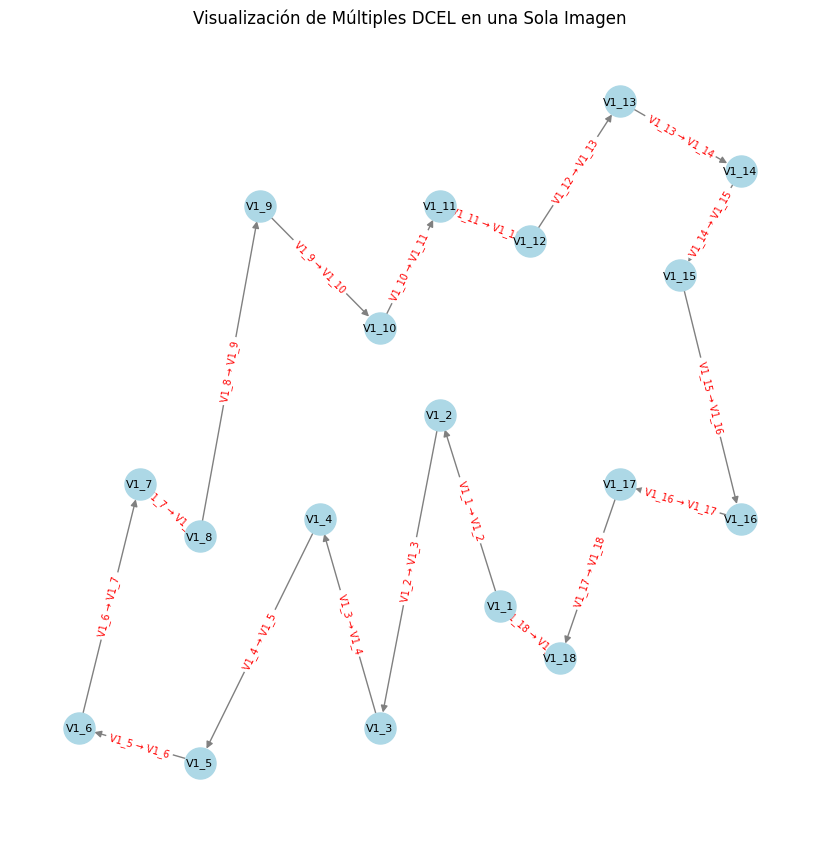

In [75]:
# CÉLULA 4: Visualizar la DCEL con NetworkX
visualize_multiple_dcel([dcel])


In [76]:
# CÉLULA 1: Clasificar vértices en tipos geométricos
import warnings
import math

def cross_z(p0, p1, p2):
    """Producto cruzado para tres puntos: determina convexidad."""
    dx1 = p1.x - p0.x
    dy1 = p1.y - p0.y
    dx2 = p2.x - p0.x
    dy2 = p2.y - p0.y
    return dx1 * dy2 - dy1 * dx2

def es_convexo(p_ant, p_act, p_sig):
    """Devuelve True si el ángulo en p_act es convexo (giro antihorario)"""
    return cross_z(p_act, p_ant, p_sig) < 0  # antihorario en sentido Y descendente

def clasificar_vertices_dcel(dcel):
    """
    Clasifica los vértices del DCEL en categorías:
    start, end, split, merge o regular.
    """
    if not dcel or not dcel.vertices:
        warnings.warn("❗ DCEL vacía o no inicializada.")
        return {}

    clasificacion = {}
    n = len(dcel.vertices)

    for i, v in enumerate(dcel.vertices):
        anterior = dcel.vertices[(i - 1) % n]
        siguiente = dcel.vertices[(i + 1) % n]

        print(f"\n🔍 Evaluando Vértice {i}: {v}")
        print(f"Vecinos → Anterior: {anterior}, Siguiente: {siguiente}")

        arriba_de_ambos = v.y > anterior.y and v.y > siguiente.y
        abajo_de_ambos = v.y < anterior.y and v.y < siguiente.y
        convexo = es_convexo(anterior, v, siguiente)

        if arriba_de_ambos:
            if convexo:
                tipo = "start"
            else:
                tipo = "split"
        elif abajo_de_ambos:
            if convexo:
                tipo = "end"
            else:
                tipo = "merge"
        else:
            tipo = "regular"

        print(f"➡ Tipo clasificado: {tipo.upper()}")
        clasificacion[v] = tipo

    return clasificacion


In [77]:
# CÉLULA 2: Prueba de clasificación sobre DCEL válida
puntos = cargar_puntos()
dcel = construir_dcel_simple(puntos)

clasificacion = clasificar_vertices_dcel(dcel)

# Supongamos que 'poly' es la lista de vértices en el orden dado por Polygon.txt
# Ejemplo de construcción (dentro de tu código, tras add_vertex):
poly = dcel.vertices[:]  # asume que los añadiste en el orden de Polygon.txt

# Ahora construimos vecinos:
vecinos = {}
n = len(poly)
for i, v in enumerate(poly):
    v_prev = poly[(i-1) % n]
    v_next = poly[(i+1) % n]
    vecinos[v] = (v_prev, v_next)


# Validar integridad
tipos_validos = {"start", "end", "split", "merge", "regular"}
verificado = True

for v, tipo in clasificacion.items():
    if tipo not in tipos_validos:
        warnings.warn(f"❗ Tipo inválido detectado: {tipo}")
        verificado = False

print("\n✅ Verificación de clasificación de vértices:", verificado)
print(f"Resumen: { {k: list(clasificacion.values()).count(k) for k in tipos_validos} }")


🔧 Total de semi-aristas creadas: 54 (con twins)
✅ Arista 0: E(V(9.0, 0.5) → V(8.0, 6.0)) → next=V(8.0, 6.0), prev=V(10.0, -1.0), face_id=2302235340112
✅ Arista 1: E(V(8.0, 6.0) → V(7.0, -3.0)) → next=V(7.0, -3.0), prev=V(9.0, 0.5), face_id=2302235340112
✅ Arista 2: E(V(7.0, -3.0) → V(6.0, 3.0)) → next=V(6.0, 3.0), prev=V(8.0, 6.0), face_id=2302235340112
✅ Arista 3: E(V(6.0, 3.0) → V(4.0, -4.0)) → next=V(4.0, -4.0), prev=V(7.0, -3.0), face_id=2302235340112
✅ Arista 4: E(V(4.0, -4.0) → V(2.0, -3.0)) → next=V(2.0, -3.0), prev=V(6.0, 3.0), face_id=2302235340112
✅ Arista 5: E(V(2.0, -3.0) → V(3.0, 4.0)) → next=V(3.0, 4.0), prev=V(4.0, -4.0), face_id=2302235340112
✅ Arista 6: E(V(3.0, 4.0) → V(4.0, 2.5)) → next=V(4.0, 2.5), prev=V(2.0, -3.0), face_id=2302235340112
✅ Arista 7: E(V(4.0, 2.5) → V(5.0, 12.0)) → next=V(5.0, 12.0), prev=V(3.0, 4.0), face_id=2302235340112
✅ Arista 8: E(V(5.0, 12.0) → V(7.0, 8.5)) → next=V(7.0, 8.5), prev=V(4.0, 2.5), face_id=2302235340112
✅ Arista 9: E(V(7.0, 8.5) 

In [78]:
# CÉLULA 1: Preparar estructura de eventos

def preparar_eventos(dcel, clasificacion):
    """
    Ordena los vértices de la DCEL para el algoritmo de barrido.
    Retorna una lista ordenada de tuplas (vértice, tipo).
    """
    if not dcel.vertices:
        raise ValueError("La DCEL no contiene vértices.")

    eventos = [(v, clasificacion[v]) for v in dcel.vertices]

    eventos.sort(key=lambda item: (-item[0].y, item[0].x))  # y descendente, x ascendente

    print("📋 Orden de eventos para el barrido (y-descendente, x-ascendente):")
    for i, (v, tipo) in enumerate(eventos):
        print(f"{i+1:02d}. {str(v)} → tipo: {tipo.upper()}")

    return eventos


In [79]:
# CÉLULA 2: Probar y verificar estructura de eventos
from itertools import pairwise
import warnings

eventos = preparar_eventos(dcel, clasificacion)

verificado = True
ys = [v.y for v, _ in eventos]
xs = [v.x for v, _ in eventos]

# Verificar orden descendente por y, y ascendente por x cuando hay empate
for i in range(1, len(eventos)):
    y0, x0 = ys[i-1], xs[i-1]
    y1, x1 = ys[i], xs[i]
    if y1 > y0 or (y1 == y0 and x1 < x0):
        warnings.warn(f"❗ Desorden detectado entre eventos {i-1} y {i}")
        verificado = False
        break

print("\n✅ Verificación de orden de eventos:", verificado)


📋 Orden de eventos para el barrido (y-descendente, x-ascendente):
01. V(11.0, 15.0) → tipo: SPLIT
02. V(13.0, 13.0) → tipo: REGULAR
03. V(5.0, 12.0) → tipo: SPLIT
04. V(8.0, 12.0) → tipo: SPLIT
05. V(9.5, 11.0) → tipo: END
06. V(12.0, 10.0) → tipo: REGULAR
07. V(7.0, 8.5) → tipo: END
08. V(8.0, 6.0) → tipo: START
09. V(3.0, 4.0) → tipo: SPLIT
10. V(11.0, 4.0) → tipo: START
11. V(6.0, 3.0) → tipo: START
12. V(13.0, 3.0) → tipo: MERGE
13. V(4.0, 2.5) → tipo: END
14. V(9.0, 0.5) → tipo: REGULAR
15. V(10.0, -1.0) → tipo: MERGE
16. V(2.0, -3.0) → tipo: REGULAR
17. V(7.0, -3.0) → tipo: MERGE
18. V(4.0, -4.0) → tipo: MERGE

✅ Verificación de orden de eventos: True


moduo 3 linea de barrido


In [80]:
# -----------------------------
# CÉLULA: Estructura completa para el barrido
# -----------------------------

class EstadoBarridoSimple:
    def __init__(self):
        self.aristas_activas = []  # Lista de tuplas (arista, helper)

    def __str__(self):
        desc = "\n📌 Estado actual del barrido:"
        for i, (e, h) in enumerate(self.aristas_activas):
            desc += f"\n  {i+1:02d}. {e} | Helper: {h}"
        return desc if self.aristas_activas else "📌 Estado vacío"

def insertar_arista(estado, arista, helper=None):
    estado.aristas_activas.append((arista, helper))
    print(f"➕ Insertada arista {arista} con helper {helper}")

def eliminar_arista(estado, arista):
    for i, (e, h) in enumerate(estado.aristas_activas):
        if e == arista:
            estado.aristas_activas.pop(i)
            print(f"➖ Eliminada arista {arista}")
            return
    print(f"⚠️ No se encontró la arista para eliminar: {arista}")

def intersecta_con_y(e, y_val):
    y1 = e.origin.y
    y2 = e.twin.origin.y
    return (y1 - y_val) * (y2 - y_val) <= 0 and y1 != y2

def x_interseccion(e, y_val):
    x1, y1 = e.origin.x, e.origin.y
    x2, y2 = e.twin.origin.x, e.twin.origin.y
    return x1 + (y_val - y1) * (x2 - x1) / (y2 - y1)

def buscar_izquierda(p, estado):
    x_p, y_p = p.x, p.y
    candidatas = []

    for e, _ in estado.aristas_activas:
        if intersecta_con_y(e, y_p):
            x_int = x_interseccion(e, y_p)
            if x_int < x_p:
                candidatas.append((x_int, e))

    if not candidatas:
        print(f"❌ No hay borde a la izquierda de {p}")
        return None

    x_mejor, e_mejor = max(candidatas, key=lambda item: item[0])
    print(f"🔎 Borde izquierdo de {p}: {e_mejor} @ x = {x_mejor}")
    return e_mejor

def set_helper(estado, arista, helper):
    for i, (e, _) in enumerate(estado.aristas_activas):
        if e == arista:
            estado.aristas_activas[i] = (e, helper)
            print(f"✅ Helper actualizado: {arista} → {helper}")
            return
    print(f"❌ No se encontró la arista para actualizar helper.")

def get_helper(estado, arista):
    for e, h in estado.aristas_activas:
        if e == arista:
            return h
    print(f"❌ No se encontró helper para {arista}")
    return None


In [81]:
# -----------------------------
# CÉLULA: PRUEBA DE buscar_izquierda CON PUNTO VALIDO
# -----------------------------

estado = EstadoBarridoSimple()

# Insertamos dos aristas para que haya al menos una intersección en y = 5.0
e1 = dcel.edges[0]  # E(V(9.0, 0.5) → V(8.0, 6.0))
e2 = dcel.edges[2]  # E(V(8.0, 6.0) → V(9.0, 0.5))

insertar_arista(estado, e1, dcel.vertices[0])
insertar_arista(estado, e2, dcel.vertices[2])

print(estado)

set_helper(estado, e1, dcel.vertices[1])
print("Helper e1:", get_helper(estado, e1))

# Punto de prueba sobre y = 5.0 (debe intersectar ambas aristas)
p_test = Vertex(9.5, 5.0)  # A la derecha de ambas aristas
_ = buscar_izquierda(p_test, estado)

eliminar_arista(estado, e1)
print(estado)


➕ Insertada arista E(V(9.0, 0.5) → V(8.0, 6.0)) con helper V(9.0, 0.5)
➕ Insertada arista E(V(8.0, 6.0) → V(9.0, 0.5)) con helper V(7.0, -3.0)

📌 Estado actual del barrido:
  01. E(V(9.0, 0.5) → V(8.0, 6.0)) | Helper: V(9.0, 0.5)
  02. E(V(8.0, 6.0) → V(9.0, 0.5)) | Helper: V(7.0, -3.0)
✅ Helper actualizado: E(V(9.0, 0.5) → V(8.0, 6.0)) → V(8.0, 6.0)
Helper e1: V(8.0, 6.0)
🔎 Borde izquierdo de V(9.5, 5.0): E(V(9.0, 0.5) → V(8.0, 6.0)) @ x = 8.181818181818182
➖ Eliminada arista E(V(9.0, 0.5) → V(8.0, 6.0))

📌 Estado actual del barrido:
  01. E(V(8.0, 6.0) → V(9.0, 0.5)) | Helper: V(7.0, -3.0)


In [84]:
# -----------------------------
# Módulo: Procesar eventos para la etapa de barrido
# -----------------------------

def handle_start_vertex(v, dcel, estado, clasificacion):
    print(f"📍 START → Insertar borde descendente desde {v}")
    aristas = [e for e in dcel.edges if e.origin == v]
    if not aristas:
        print(f"⚠️ No se encontró arista saliente desde {v}")
        return
    descendente = min(aristas, key=lambda e: e.twin.origin.y)
    insertar_arista(estado, descendente, v)

def handle_end_vertex(v, dcel, estado, clasificacion, diagonales):
    print(f"📍 END → Procesar vértice {v}")
    incidente = None
    helper = None
    for e, h in estado.aristas_activas:
        if e.twin.origin == v:
            incidente = e
            helper = h
            break
    if incidente is None:
        print(f"⚠️ No se encontró arista incidente para {v}")
        return
    tipo_helper = clasificacion.get(helper, "").lower()
    if tipo_helper == "merge":
        print(f"➕ Insertar diagonal: {v} ↔ {helper}")
        diagonales.append((v, helper))
        cara = encontrar_cara_comun(dcel, v, helper)
        if cara:
            insertar_diagonal_y_actualizar_caras(dcel, v, helper, cara)
        else:
            print(f"❌ No se encontró cara común para insertar diagonal {v} ↔ {helper}")
    eliminar_arista(estado, incidente)

def handle_split_vertex(v, dcel, estado, clasificacion, diagonales):
    print(f"📍 SPLIT → Procesar vértice {v}")
    borde_izquierdo = buscar_izquierda(v, estado)
    if borde_izquierdo:
        helper = get_helper(estado, borde_izquierdo)
        if helper:
            print(f"🔎 Helper del borde izquierdo: {helper}")
            print(f"➕ Insertar diagonal: {v} ↔ {helper}")
            diagonales.append((v, helper))
            cara = encontrar_cara_comun(dcel, v, helper)
            if cara:
                insertar_diagonal_y_actualizar_caras(dcel, v, helper, cara)
            else:
                print(f"❌ No se encontró cara común para insertar diagonal {v} ↔ {helper}")
        set_helper(estado, borde_izquierdo, v)
    else:
        print(f"⚠️ No se encontró borde a la izquierda de {v}")
    salientes = [e for e in dcel.edges if e.origin == v]
    if not salientes:
        print(f"⚠️ No se encontró arista descendente desde {v}")
        return
    descendente = min(salientes, key=lambda e: e.twin.origin.y)
    insertar_arista(estado, descendente, v)

def handle_merge_vertex(v, dcel, estado, clasificacion, diagonales):
    print(f"📍 MERGE → Procesar vértice {v}")
    incidentes = [e for e in dcel.edges if e.twin.origin == v]
    if incidentes:
        incidente = incidentes[0]
        helper = get_helper(estado, incidente)
        if helper and clasificacion.get(helper, "").lower() == "merge":
            print(f"➕ Insertar diagonal: {v} ↔ {helper}")
            diagonales.append((v, helper))
            cara = encontrar_cara_comun(dcel, v, helper)
            if cara:
                insertar_diagonal_y_actualizar_caras(dcel, v, helper, cara)
            else:
                print(f"❌ No se encontró cara común para insertar diagonal {v} ↔ {helper}")
        eliminar_arista(estado, incidente)
    else:
        print(f"⚠️ No se encontró arista incidente a {v}")
    borde_izq = buscar_izquierda(v, estado)
    if borde_izq:
        helper_izq = get_helper(estado, borde_izq)
        if helper_izq and clasificacion.get(helper_izq, "").lower() == "merge":
            print(f"➕ Insertar diagonal: {v} ↔ {helper_izq}")
            diagonales.append((v, helper_izq))
            cara = encontrar_cara_comun(dcel, v, helper_izq)
            if cara:
                insertar_diagonal_y_actualizar_caras(dcel, v, helper_izq, cara)
            else:
                print(f"❌ No se encontró cara común para insertar diagonal {v} ↔ {helper_izq}")
        set_helper(estado, borde_izq, v)
    else:
        print(f"❌ No hay borde a la izquierda de {v}")

def handle_regular_vertex(v, dcel, estado, clasificacion):
    print(f"📍 REGULAR → Procesar vértice {v}")
    e0 = next((e for e in dcel.edges if e.origin == v and e.next and e.prev), None)
    if not e0:
        print(f"⚠️ No se encontró arista conectada desde {v}")
        return
    v_next = e0.next.origin
    if v_next.y < v.y:
        print(f"↘ REGULAR como START")
        insertar_arista(estado, e0, v)
    else:
        print(f"↖ REGULAR como END")
        incidente = e0.prev
        helper = get_helper(estado, incidente)
        if helper and clasificacion.get(helper, "") == "merge":
            print(f"➕ Insertar diagonal: {v} ↔ {helper}")
        eliminar_arista(estado, incidente)

def procesar_eventos(eventos, clasificacion, dcel):
    estado = EstadoBarridoSimple()
    diagonales = []
    print("\n🚀 Iniciando barrido vertical...\n")
    for i, (v, tipo) in enumerate(eventos):
        print(f"\n🔹 Evento {i+1:02d}: {v} → tipo: {tipo.upper()}")
        tipo_lower = tipo.lower()
        if tipo_lower == "start":
            handle_start_vertex(v, dcel, estado, clasificacion)
        elif tipo_lower == "end":
            handle_end_vertex(v, dcel, estado, clasificacion, diagonales)
        elif tipo_lower == "merge":
            handle_merge_vertex(v, dcel, estado, clasificacion, diagonales)
        elif tipo_lower == "split":
            handle_split_vertex(v, dcel, estado, clasificacion, diagonales)
        elif tipo_lower == "regular":
            handle_regular_vertex(v, dcel, estado, clasificacion)
        else:
            print(f"⚠️ Tipo desconocido: {tipo}")
        print(estado)
        print("-" * 50)
    print("\n✅ Barrido finalizado.")
    return estado, diagonales


In [85]:
# -----------------------------
# CÉLULA: Simular barrido para START
# -----------------------------

estado_final, diagonales = procesar_eventos(eventos, clasificacion, dcel)



🚀 Iniciando barrido vertical...


🔹 Evento 01: V(11.0, 15.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(11.0, 15.0)
❌ No hay borde a la izquierda de V(11.0, 15.0)
⚠️ No se encontró borde a la izquierda de V(11.0, 15.0)
➕ Insertada arista E(V(11.0, 15.0) → V(9.5, 11.0)) con helper V(11.0, 15.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
--------------------------------------------------

🔹 Evento 02: V(13.0, 13.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice V(13.0, 13.0)
↘ REGULAR como START
➕ Insertada arista E(V(13.0, 13.0) → V(12.0, 10.0)) con helper V(13.0, 13.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
  02. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
--------------------------------------------------

🔹 Evento 03: V(5.0, 12.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(5.0, 12.0)
❌ No hay borde a la izquierda de V(5.0, 12.0)
⚠️ No se encontró borde a la izquierda de V

In [86]:
# Volver a importar matplotlib tras el reinicio del kernel
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Colores asociados a cada tipo de evento
COLOR_EVENTO = {
    "start": "green",
    "end": "red",
    "split": "orange",
    "merge": "purple",
    "regular": "blue"
}


# Función principal para visualizar estado completo con filtros
def visualizar_estado_completo(dcel, estado, clasificacion, tipo_evento=None, diagonales=None, titulo="Estado del Barrido Completo"):
    fig, ax = plt.subplots(figsize=(10, 10))

    # 1. Dibujar todas las aristas del polígono
    for edge in dcel.edges:
        x0, y0 = edge.origin.x, edge.origin.y
        x1, y1 = edge.twin.origin.x, edge.twin.origin.y
        ax.plot([x0, x1], [y0, y1], color='lightgray', linewidth=1, zorder=1)

    # 2. Dibujar vértices con índice y tipo
    for idx, v in enumerate(dcel.vertices):
        tipo = clasificacion.get(v, None)
        if tipo_evento is None or tipo == tipo_evento:
            color = COLOR_EVENTO.get(tipo, "gray")
            ax.plot(v.x, v.y, 'o', color=color, zorder=2)
            ax.text(v.x + 0.1, v.y + 0.1, f"{tipo if tipo else '?'}\ni={idx}", fontsize=7, color=color)

    # 3. Dibujar aristas activas
    colores_estado = ['blue', 'green', 'purple', 'orange', 'cyan']
    for i, (edge, helper) in enumerate(estado.aristas_activas):
        color = colores_estado[i % len(colores_estado)]
        x0, y0 = edge.origin.x, edge.origin.y
        x1, y1 = edge.twin.origin.x, edge.twin.origin.y
        ax.plot([x0, x1], [y0, y1], '-', color=color, linewidth=2, zorder=3)
        if helper:
            ax.text((x0+x1)/2, (y0+y1)/2, f"H:({helper.x:.1f}, {helper.y:.1f})", fontsize=8, color=color)

    # 4. Dibujar diagonales
    if diagonales:
        for v1, v2 in diagonales:
            try:
                i1 = dcel.vertices.index(v1)
                i2 = dcel.vertices.index(v2)
                ax.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', linewidth=1.5, zorder=4)
                mid_x, mid_y = (v1.x + v2.x)/2, (v1.y + v2.y)/2
                ax.text(mid_x, mid_y, f"({i1},{i2})", fontsize=8, color='red')
            except ValueError:
                print(f"⚠️ Diagonal no se pudo indexar: {v1}, {v2}")

    ax.set_aspect('equal')
    ax.set_title(titulo, fontsize=14)
    ax.grid(True)
    plt.show()







In [87]:
def procesar_eventos_con_visual_debug(eventos, clasificacion, dcel, debug_types=None, visualizar=False):
    estado = EstadoBarridoSimple()
    diagonales = []

    print("\n🚀 Iniciando barrido vertical con debug visual...\n")
    for i, (v, tipo) in enumerate(eventos):
        tipo_low = tipo.lower()
        print(f"\n🔷 Evento {i+1:02d}: {v} → tipo: {tipo.upper()}")

        if tipo_low == "start":
            handle_start_vertex(v, dcel, estado, clasificacion)

        elif tipo_low == "end":
            handle_end_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo_low == "split":
            handle_split_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo_low == "merge":
            handle_merge_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo_low == "regular":
            handle_regular_vertex(v, dcel, estado, clasificacion)

        else:
            print(f"⚠️ Tipo desconocido: {tipo}")

        # Mostrar logs de estado y diagonales
        print(estado)
        if diagonales:
            print("📐 Diagonales registradas:")
            for a, b in diagonales:
                try:
                    ia = dcel.vertices.index(a)
                    ib = dcel.vertices.index(b)
                    print(f"   • {a} ↔ {b}  → índices: ({ia}, {ib})")
                except ValueError:
                    print(f"   • {a} ↔ {b}  → ⚠️ uno no está en dcel.vertices")

        # Visualización condicional
        if visualizar or (debug_types and tipo_low in [t.lower() for t in debug_types]):
            visualizar_estado_completo(
                dcel=dcel,
                estado=estado,
                clasificacion=clasificacion,
                diagonales=diagonales,
                tipo_evento=None,
                titulo=f"Evento {i+1}: {tipo.upper()}"
            )
            input("⏸ Presiona Enter para continuar...")

    print("\n✅ Barrido finalizado.")
    return estado, diagonales


In [88]:
# Volver a cargar los módulos necesarios tras el reset del kernel
import matplotlib.pyplot as plt

# Definición de función de depuración visual para buscar izquierda
def debug_buscar_izquierda(v, estado):
    """
    Visualiza el proceso de búsqueda del borde activo a la izquierda del vértice v.
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    # Dibujar el vértice actual
    ax.plot(v.x, v.y, 'ro', label=f'Vertice v ({v.x}, {v.y})')

    # Dibujar línea horizontal hacia la izquierda desde v
    ax.plot([v.x - 5, v.x], [v.y, v.y], 'r--', alpha=0.5)

    mejor = None
    mejor_x = float('-inf')

    for edge, helper in estado.aristas_activas:
        x0, y0 = edge.origin.x, edge.origin.y
        x1, y1 = edge.twin.origin.x, edge.twin.origin.y
        ax.plot([x0, x1], [y0, y1], 'gray')

        if y0 == y1:
            continue  # horizontal, no cruza

        if (y0 < v.y and y1 > v.y) or (y1 < v.y and y0 > v.y):
            # Cruza la horizontal desde v
            x_inter = x0 + (v.y - y0) * (x1 - x0) / (y1 - y0)
            if x_inter < v.x and x_inter > mejor_x:
                mejor_x = x_inter
                mejor = edge

    # Dibujar mejor borde
    if mejor:
        x0, y0 = mejor.origin.x, mejor.origin.y
        x1, y1 = mejor.twin.origin.x, mejor.twin.origin.y
        ax.plot([x0, x1], [y0, y1], 'g-', linewidth=3, label='Borde izquierdo encontrado')

    ax.set_title("Debug búsqueda de borde izquierdo")
    ax.legend()
    ax.grid(True)
    ax.set_aspect('equal')
    plt.show()

    return mejor


🔧 Total de semi-aristas creadas: 54 (con twins)
✅ Arista 0: E(V(9.0, 0.5) → V(8.0, 6.0)) → next=V(8.0, 6.0), prev=V(10.0, -1.0), face_id=2302236688704
✅ Arista 1: E(V(8.0, 6.0) → V(7.0, -3.0)) → next=V(7.0, -3.0), prev=V(9.0, 0.5), face_id=2302236688704
✅ Arista 2: E(V(7.0, -3.0) → V(6.0, 3.0)) → next=V(6.0, 3.0), prev=V(8.0, 6.0), face_id=2302236688704
✅ Arista 3: E(V(6.0, 3.0) → V(4.0, -4.0)) → next=V(4.0, -4.0), prev=V(7.0, -3.0), face_id=2302236688704
✅ Arista 4: E(V(4.0, -4.0) → V(2.0, -3.0)) → next=V(2.0, -3.0), prev=V(6.0, 3.0), face_id=2302236688704
✅ Arista 5: E(V(2.0, -3.0) → V(3.0, 4.0)) → next=V(3.0, 4.0), prev=V(4.0, -4.0), face_id=2302236688704
✅ Arista 6: E(V(3.0, 4.0) → V(4.0, 2.5)) → next=V(4.0, 2.5), prev=V(2.0, -3.0), face_id=2302236688704
✅ Arista 7: E(V(4.0, 2.5) → V(5.0, 12.0)) → next=V(5.0, 12.0), prev=V(3.0, 4.0), face_id=2302236688704
✅ Arista 8: E(V(5.0, 12.0) → V(7.0, 8.5)) → next=V(7.0, 8.5), prev=V(4.0, 2.5), face_id=2302236688704
✅ Arista 9: E(V(7.0, 8.5) 

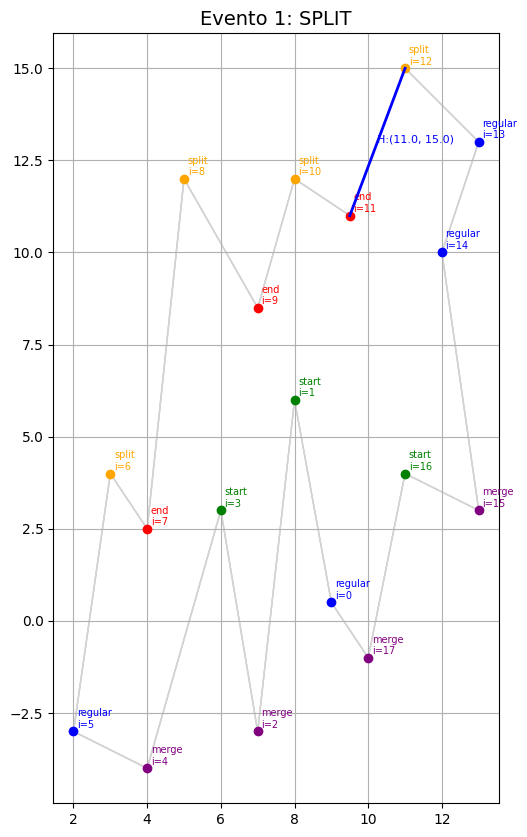


🔷 Evento 02: V(13.0, 13.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice V(13.0, 13.0)
↘ REGULAR como START
➕ Insertada arista E(V(13.0, 13.0) → V(12.0, 10.0)) con helper V(13.0, 13.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
  02. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)

🔷 Evento 03: V(5.0, 12.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(5.0, 12.0)
❌ No hay borde a la izquierda de V(5.0, 12.0)
⚠️ No se encontró borde a la izquierda de V(5.0, 12.0)
➕ Insertada arista E(V(5.0, 12.0) → V(4.0, 2.5)) con helper V(5.0, 12.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
  02. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  03. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(5.0, 12.0)


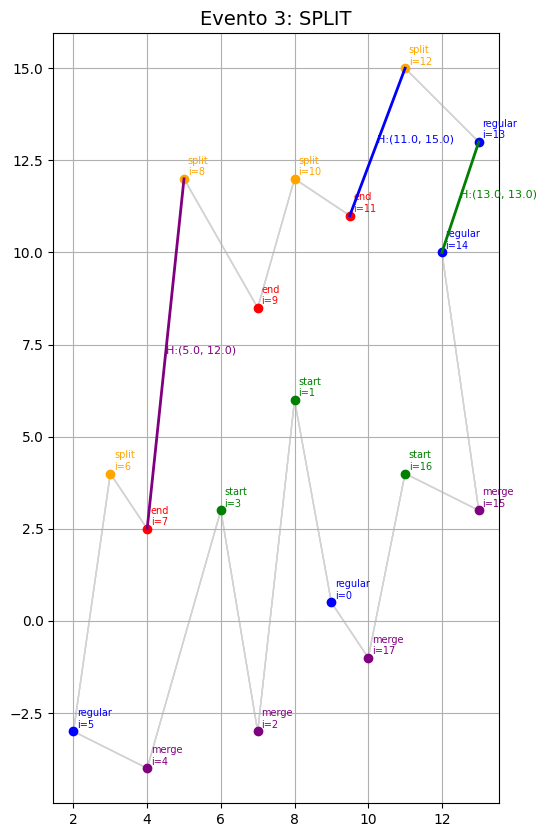


🔷 Evento 04: V(8.0, 12.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(8.0, 12.0)
🔎 Borde izquierdo de V(8.0, 12.0): E(V(5.0, 12.0) → V(4.0, 2.5)) @ x = 5.0
🔎 Helper del borde izquierdo: V(5.0, 12.0)
➕ Insertar diagonal: V(8.0, 12.0) ↔ V(5.0, 12.0)
✅ Cara encontrada para la diagonal entre V(8.0, 12.0) y V(5.0, 12.0)
✅ Helper actualizado: E(V(5.0, 12.0) → V(4.0, 2.5)) → V(8.0, 12.0)
➕ Insertada arista E(V(8.0, 12.0) → V(7.0, 8.5)) con helper V(8.0, 12.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
  02. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  03. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  04. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 12.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)  → índices: (10, 8)


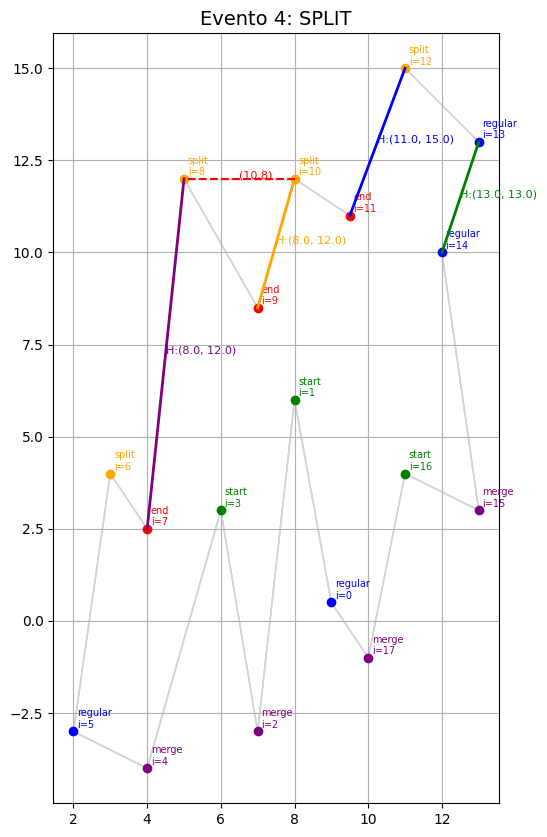


🔷 Evento 05: V(9.5, 11.0) → tipo: END
📍 END → Procesar vértice V(9.5, 11.0)
➖ Eliminada arista E(V(11.0, 15.0) → V(9.5, 11.0))

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  03. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 12.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)  → índices: (10, 8)

🔷 Evento 06: V(12.0, 10.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice V(12.0, 10.0)
↘ REGULAR como START
➕ Insertada arista E(V(12.0, 10.0) → V(13.0, 3.0)) con helper V(12.0, 10.0)

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  03. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 12.0)
  04. E(V(12.0, 10.0) → V(13.0, 3.0)) | Helper: V(12.0, 10.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)  → índices: (10, 8)

🔷 Evento 07: V(7.0, 8.5) → tipo: END
📍 END → 

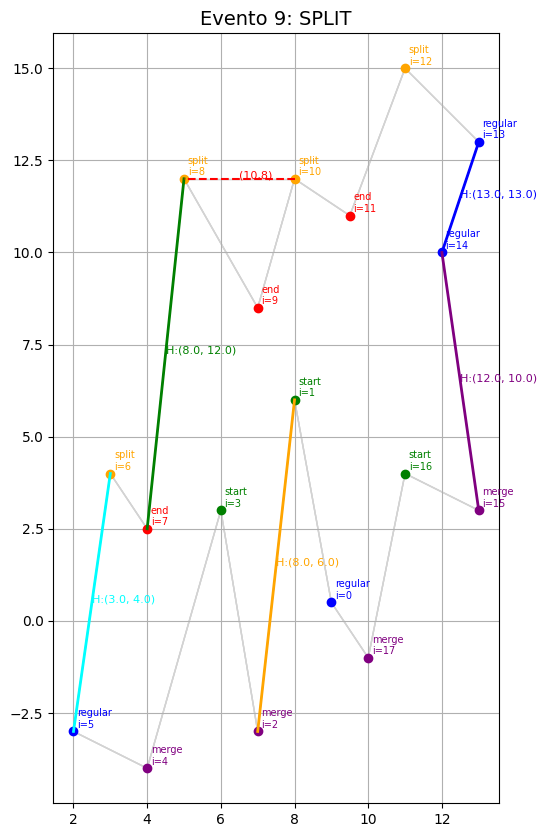


🔷 Evento 10: V(11.0, 4.0) → tipo: START
📍 START → Insertar borde descendente desde V(11.0, 4.0)
➕ Insertada arista E(V(11.0, 4.0) → V(10.0, -1.0)) con helper V(11.0, 4.0)

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  03. E(V(12.0, 10.0) → V(13.0, 3.0)) | Helper: V(12.0, 10.0)
  04. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)
  05. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  06. E(V(11.0, 4.0) → V(10.0, -1.0)) | Helper: V(11.0, 4.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)  → índices: (10, 8)

🔷 Evento 11: V(6.0, 3.0) → tipo: START
📍 START → Insertar borde descendente desde V(6.0, 3.0)
➕ Insertada arista E(V(6.0, 3.0) → V(4.0, -4.0)) con helper V(6.0, 3.0)

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  03. E(V(12.0, 10.0) → V(13.0, 3.0)) |

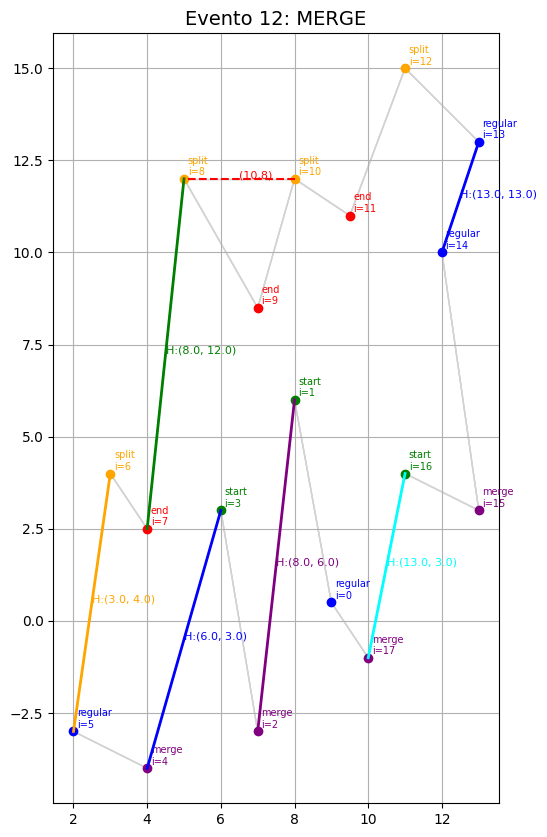


🔷 Evento 13: V(4.0, 2.5) → tipo: END
📍 END → Procesar vértice V(4.0, 2.5)
➖ Eliminada arista E(V(5.0, 12.0) → V(4.0, 2.5))

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)
  03. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  04. E(V(11.0, 4.0) → V(10.0, -1.0)) | Helper: V(13.0, 3.0)
  05. E(V(6.0, 3.0) → V(4.0, -4.0)) | Helper: V(6.0, 3.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)  → índices: (10, 8)

🔷 Evento 14: V(9.0, 0.5) → tipo: REGULAR
📍 REGULAR → Procesar vértice V(9.0, 0.5)
↖ REGULAR como END
❌ No se encontró helper para E(V(10.0, -1.0) → V(9.0, 0.5))
⚠️ No se encontró la arista para eliminar: E(V(10.0, -1.0) → V(9.0, 0.5))

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)
  03. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  04. E(V(11.0, 4.0) → V

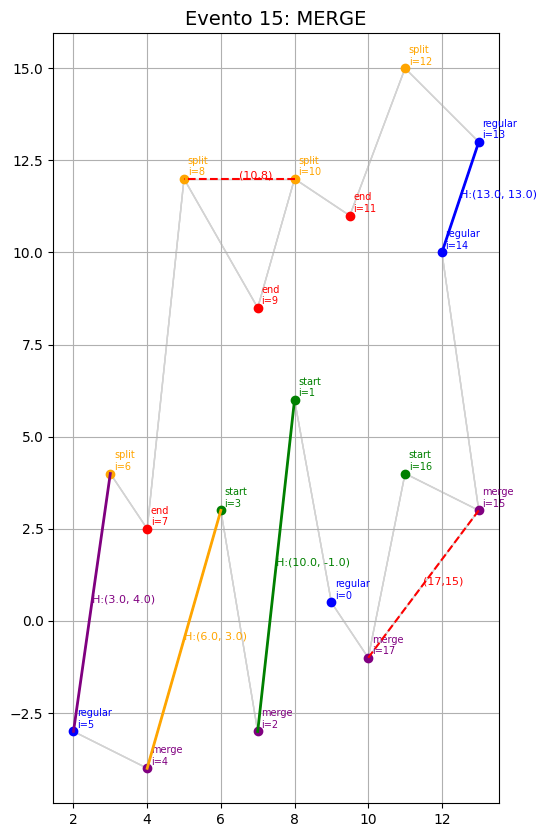


🔷 Evento 16: V(2.0, -3.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice V(2.0, -3.0)
↖ REGULAR como END
❌ No se encontró helper para E(V(4.0, -4.0) → V(2.0, -3.0))
⚠️ No se encontró la arista para eliminar: E(V(4.0, -4.0) → V(2.0, -3.0))

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(10.0, -1.0)
  03. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  04. E(V(6.0, 3.0) → V(4.0, -4.0)) | Helper: V(6.0, 3.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)  → índices: (10, 8)
   • V(10.0, -1.0) ↔ V(13.0, 3.0)  → índices: (17, 15)

🔷 Evento 17: V(7.0, -3.0) → tipo: MERGE
📍 MERGE → Procesar vértice V(7.0, -3.0)
➕ Insertar diagonal: V(7.0, -3.0) ↔ V(10.0, -1.0)
✅ Cara encontrada para la diagonal entre V(7.0, -3.0) y V(10.0, -1.0)
➖ Eliminada arista E(V(8.0, 6.0) → V(7.0, -3.0))
🔎 Borde izquierdo de V(7.0, -3.0): E(V(6.0, 3.0) → V(4.0, -4.0)) @ x = 4.285714285714286
✅ Helper actualizado

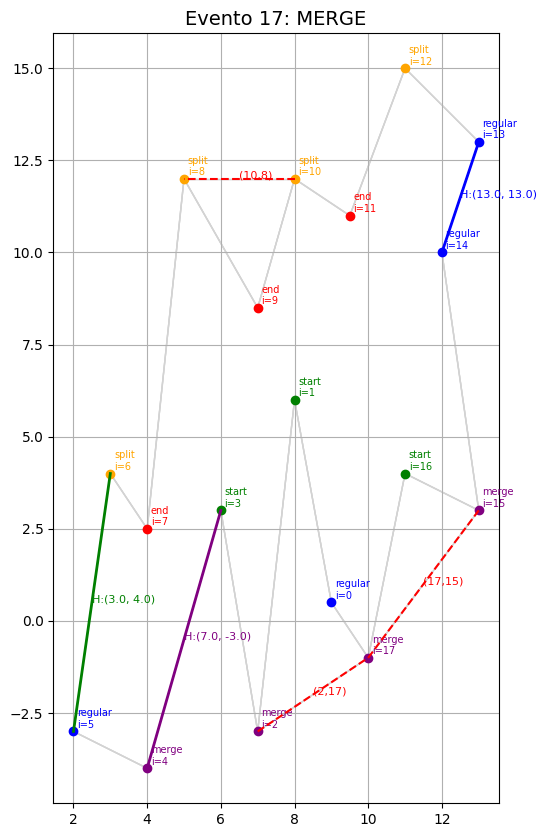


🔷 Evento 18: V(4.0, -4.0) → tipo: MERGE
📍 MERGE → Procesar vértice V(4.0, -4.0)
➕ Insertar diagonal: V(4.0, -4.0) ↔ V(7.0, -3.0)
✅ Cara encontrada para la diagonal entre V(4.0, -4.0) y V(7.0, -3.0)
➖ Eliminada arista E(V(6.0, 3.0) → V(4.0, -4.0))
❌ No hay borde a la izquierda de V(4.0, -4.0)
❌ No hay borde a la izquierda de V(4.0, -4.0)

📌 Estado actual del barrido:
  01. E(V(13.0, 13.0) → V(12.0, 10.0)) | Helper: V(13.0, 13.0)
  02. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)  → índices: (10, 8)
   • V(10.0, -1.0) ↔ V(13.0, 3.0)  → índices: (17, 15)
   • V(7.0, -3.0) ↔ V(10.0, -1.0)  → índices: (2, 17)
   • V(4.0, -4.0) ↔ V(7.0, -3.0)  → índices: (4, 2)


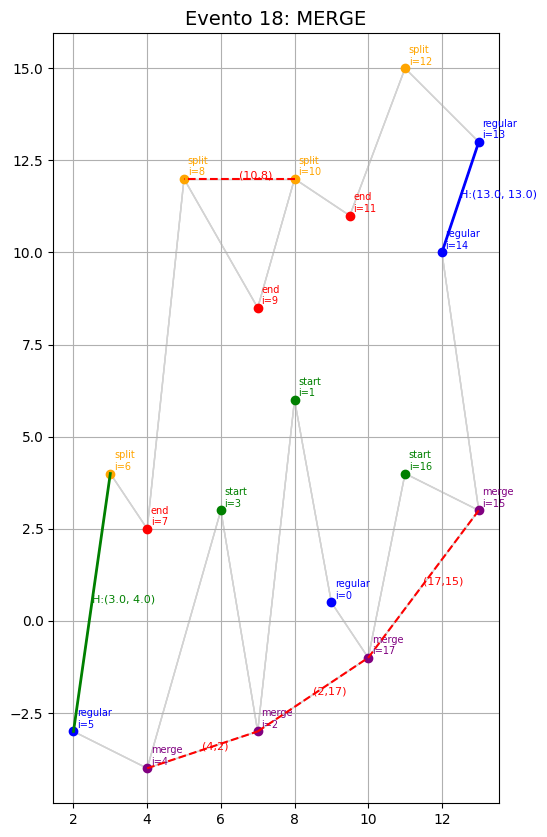


✅ Barrido finalizado.


In [89]:
#modulo de verificacion de los eventos de la clasificacion

puntos = cargar_puntos()
dcel = construir_dcel_simple(puntos)
clasificacion = clasificar_vertices_dcel(dcel)
eventos = preparar_eventos(dcel, clasificacion)


#estado_final, diagonales = procesar_eventos(eventos, clasificacion, dcel)
estado_final, diagonales_final = procesar_eventos_con_visual_debug(
    eventos=eventos,
    clasificacion=clasificacion,
    dcel=dcel,
    debug_types=["split", "merge"],  # Visualizar solo estos tipos
    visualizar=False                 # O True para ver todos
)

#
# 





# 
# 
# 
# 
# estado, diagonales = procesar_eventos_con_visual_debug(eventos, clasificacion, dcel)


triangulacion

In [64]:



def verificar_integridad_dcel(dcel):
    errores = 0
    print("🔎 Verificando integridad de la DCEL...\n")

    for i, e in enumerate(dcel.edges):
        if e.next is None:
            print(f"❌ Arista {i} sin .next → {e}")
            errores += 1
        if e.prev is None:
            print(f"❌ Arista {i} sin .prev → {e}")
            errores += 1
        if e.twin is None:
            print(f"❌ Arista {i} sin .twin → {e}")
            errores += 1
        if e.incident_face is None:
            print(f"❌ Arista {i} sin .incident_face → {e}")
            errores += 1

    # Validación de ciclos cerrados en caras
    # Validación de ciclos cerrados en caras
    for i, face in enumerate(dcel.faces):
        if not face.outer_component:
            print(f"⚠️  Cara {i} sin outer_component.")
            continue

        recorrido = set()
        start = face.outer_component
        edge = start

        while True:
            if edge in recorrido:
                print(f"❌ Bucle detectado en cara {i}: la arista ya fue visitada. Arista: {edge}")
                errores += 1
                break
            recorrido.add(edge)

            if edge.next is None:
                print(f"❌ Ciclo roto en cara {i}: .next es None en {edge}")
                errores += 1
                break

            edge = edge.next
            if edge == start:
                break

    if edge != start:
        print(f"❌ Ciclo roto en cara {i} (no retorna al inicio).")
        errores += 1


    if errores == 0:
        print("✅ La estructura de la DCEL es consistente.")
    else:
        print(f"⚠️ Se detectaron {errores} problemas de integridad.")

    return errores == 0

def visualizar_dos_caras(face1, face2, diagonal=None):
    def extraer_coords(face):
        coords = []
        start = face.outer_component
        edge = start
        while True:
            coords.append((edge.origin.x, edge.origin.y))
            edge = edge.next
            if edge == start or edge is None:
                break
        return coords + [coords[0]]

    plt.figure(figsize=(6,6))

    coords1 = extraer_coords(face1)
    coords2 = extraer_coords(face2)

    plt.plot(*zip(*coords1), 'b-o', label='Cara 1')
    plt.plot(*zip(*coords2), 'g-s', label='Cara 2')

    if diagonal:
        v1, v2 = diagonal
        plt.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', label='Diagonal')

    plt.title("Visualización de las dos nuevas caras")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()




In [65]:
puntos = cargar_puntos()
dcel = construir_dcel_simple(puntos)
clasificacion = clasificar_vertices_dcel(dcel)
eventos = preparar_eventos(dcel, clasificacion)


estado_final, diagonales = procesar_eventos(eventos, clasificacion, dcel)

for v1, v2 in diagonales:
    cara = encontrar_cara_comun(dcel, v1, v2)
    if cara:
        insertar_diagonal_y_actualizar_caras(dcel, v1, v2, cara)
verificar_integridad_dcel(dcel)
#visualizar_dos_caras(f1, f2, diagonal=(v1, v2))


🔧 Total de semi-aristas creadas: 54 (con twins)
✅ Arista 0: E(V(9.0, 0.5) → V(8.0, 6.0)) → next=V(8.0, 6.0), prev=V(10.0, -1.0), face_id=2304231484464
✅ Arista 1: E(V(8.0, 6.0) → V(7.0, -3.0)) → next=V(7.0, -3.0), prev=V(9.0, 0.5), face_id=2304231484464
✅ Arista 2: E(V(7.0, -3.0) → V(6.0, 3.0)) → next=V(6.0, 3.0), prev=V(8.0, 6.0), face_id=2304231484464
✅ Arista 3: E(V(6.0, 3.0) → V(4.0, -4.0)) → next=V(4.0, -4.0), prev=V(7.0, -3.0), face_id=2304231484464
✅ Arista 4: E(V(4.0, -4.0) → V(2.0, -3.0)) → next=V(2.0, -3.0), prev=V(6.0, 3.0), face_id=2304231484464
✅ Arista 5: E(V(2.0, -3.0) → V(3.0, 4.0)) → next=V(3.0, 4.0), prev=V(4.0, -4.0), face_id=2304231484464
✅ Arista 6: E(V(3.0, 4.0) → V(4.0, 2.5)) → next=V(4.0, 2.5), prev=V(2.0, -3.0), face_id=2304231484464
✅ Arista 7: E(V(4.0, 2.5) → V(5.0, 12.0)) → next=V(5.0, 12.0), prev=V(3.0, 4.0), face_id=2304231484464
✅ Arista 8: E(V(5.0, 12.0) → V(7.0, 8.5)) → next=V(7.0, 8.5), prev=V(4.0, 2.5), face_id=2304231484464
✅ Arista 9: E(V(7.0, 8.5) 

False

In [66]:
def obtener_vertices_cara(face):
    """
    Devuelve una lista ordenada de vértices (sin repetidos) que forman el contorno de la cara.
    """
    vertices = []
    start = face.outer_component
    edge = start
    visitados = set()
    
    while edge and edge not in visitados:
        visitados.add(edge)
        vertices.append(edge.origin)
        edge = edge.next
        if edge == start:
            break
    return vertices

def listar_caras_candidatas_para_triangulacion(dcel):
    """
    Imprime información de las caras con más de 3 vértices, útiles para triangulación.
    """
    print("\n🔍 Caras con más de 3 vértices (candidatas a triangulación):\n")
    for i, cara in enumerate(dcel.faces):
        if cara.outer_component is None:
            print(f"⚠️ Cara {i} sin outer_component, se omite.")
            continue

        vertices = obtener_vertices_cara(cara)
        n = len(vertices)

        if n > 3:
            print(f"🟢 Cara {i} → {n} vértices")
            for j, v in enumerate(vertices):
                print(f"   {j+1:>2}: V({v.x}, {v.y})")
        else:
            print(f"🔹 Cara {i} tiene solo {n} vértices, ya es un triángulo.")


def obtener_caras_candidatas(dcel):
    """
    Retorna una lista de caras con más de 3 vértices (no trianguladas).
    """
    candidatas = []
    for cara in dcel.faces:
        if cara.outer_component:
            vertices = obtener_vertices_cara(cara)
            if len(vertices) > 3:
                candidatas.append(cara)
    return candidatas



In [67]:
def visualizar_cara_con_indices(cara, dcel, diagonal=None, titulo="Cara seleccionada"):
    """
    Dibuja la cara dada mostrando:
    - Índices locales
    - Índices globales
    - Coordenadas
    - Dirección del borde
    - (Opcional) Diagonal resaltada
    """
    vertices = obtener_vertices_cara(cara)
    coords = [(v.x, v.y) for v in vertices]
    coords.append(coords[0])  # cerrar el ciclo

    plt.figure(figsize=(6, 6))
    x, y = zip(*coords)
    plt.plot(x, y, 'o-k', linewidth=1.5)

    for i, (vx, vy) in enumerate(coords[:-1]):
        v = vertices[i]
        global_id = dcel.vertices.index(v)
        label = f"{i} [id={global_id}]\n({vx:.1f}, {vy:.1f})"
        plt.text(vx + 0.1, vy + 0.1, label, fontsize=8, color='blue')

    # Flecha que indica dirección del borde
    plt.annotate("", xy=coords[1], xytext=coords[0],
                 arrowprops=dict(arrowstyle="->", color='gray', lw=1.2))

    # Dibujar diagonal (opcional)
    if diagonal:
        v1, v2 = diagonal
        plt.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', linewidth=2, label="Diagonal nueva")

    plt.title(titulo)
    plt.axis('equal')
    plt.grid(True)
    if diagonal:
        plt.legend()
    plt.show()


In [ ]:
puntos = cargar_puntos()
dcel = construir_dcel_simple(puntos)
clasificacion = clasificar_vertices_dcel(dcel)
eventos = preparar_eventos(dcel, clasificacion)
estado_final, diagonales = procesar_eventos(eventos, clasificacion, dcel)

for v1, v2 in diagonales:
    cara = encontrar_cara_comun(dcel, v1, v2)
    if cara:
        insertar_diagonal_y_actualizar_caras(dcel, v1, v2, cara)

verificar_integridad_dcel(dcel)
caras_candidatas = obtener_caras_candidatas(dcel)



🔧 Total de semi-aristas creadas: 54 (con twins)
✅ Arista 0: E(V(9.0, 0.5) → V(8.0, 6.0)) → next=V(8.0, 6.0), prev=V(10.0, -1.0), face_id=2302232404208
✅ Arista 1: E(V(8.0, 6.0) → V(7.0, -3.0)) → next=V(7.0, -3.0), prev=V(9.0, 0.5), face_id=2302232404208
✅ Arista 2: E(V(7.0, -3.0) → V(6.0, 3.0)) → next=V(6.0, 3.0), prev=V(8.0, 6.0), face_id=2302232404208
✅ Arista 3: E(V(6.0, 3.0) → V(4.0, -4.0)) → next=V(4.0, -4.0), prev=V(7.0, -3.0), face_id=2302232404208
✅ Arista 4: E(V(4.0, -4.0) → V(2.0, -3.0)) → next=V(2.0, -3.0), prev=V(6.0, 3.0), face_id=2302232404208
✅ Arista 5: E(V(2.0, -3.0) → V(3.0, 4.0)) → next=V(3.0, 4.0), prev=V(4.0, -4.0), face_id=2302232404208
✅ Arista 6: E(V(3.0, 4.0) → V(4.0, 2.5)) → next=V(4.0, 2.5), prev=V(2.0, -3.0), face_id=2302232404208
✅ Arista 7: E(V(4.0, 2.5) → V(5.0, 12.0)) → next=V(5.0, 12.0), prev=V(3.0, 4.0), face_id=2302232404208
✅ Arista 8: E(V(5.0, 12.0) → V(7.0, 8.5)) → next=V(7.0, 8.5), prev=V(4.0, 2.5), face_id=2302232404208
✅ Arista 9: E(V(7.0, 8.5) 

Visualizando cara candidata 0 con 5 vértices...


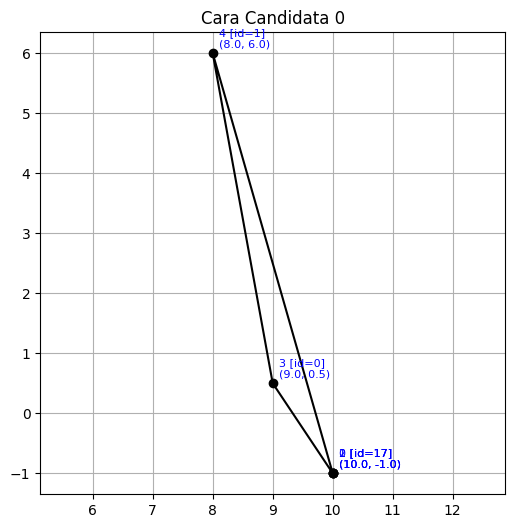

Visualizando cara candidata 1 con 11 vértices...


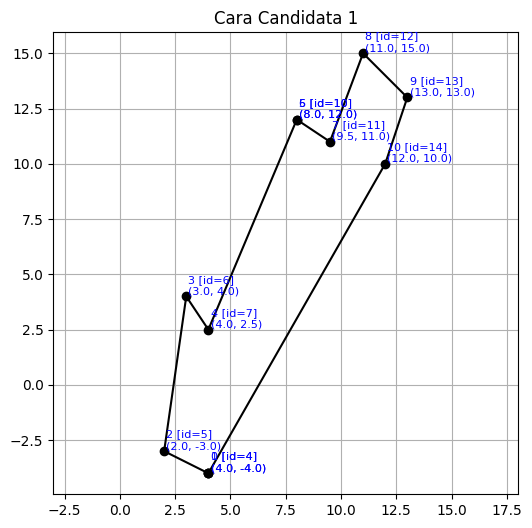

Visualizando cara candidata 2 con 4 vértices...


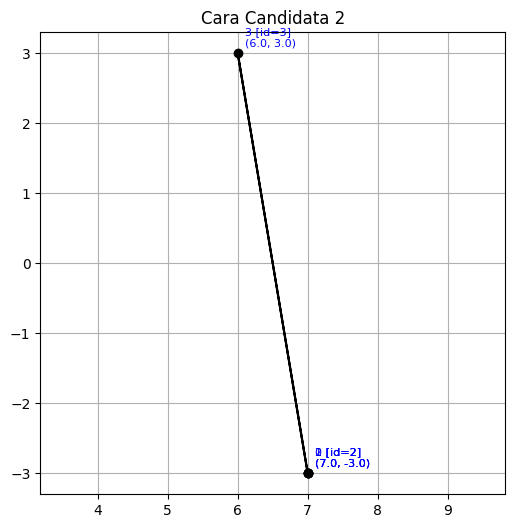

In [33]:
for i, cara in enumerate(caras_candidatas):
    print(f"Visualizando cara candidata {i} con {len(obtener_vertices_cara(cara))} vértices...")
    visualizar_cara_con_indices(cara, dcel, titulo=f"Cara Candidata {i}")


In [38]:
def triangular_cara_y_monotona(face):
    """
    Recibe una cara y-monótona (ordenada antihorario) y devuelve una lista de diagonales necesarias
    para triangularla completamente. Cada diagonal es un par de vértices (v1, v2).
    """
    vertices = obtener_vertices_cara(face)
    n = len(vertices)

    # Ordenar por coordenada Y descendente (si hay empate, usar X ascendente)
    ordenados = sorted(vertices, key=lambda v: (-v.y, v.x))

    # Clasificar vértices como parte de la cadena izquierda o derecha
    idx_max = vertices.index(max(vertices, key=lambda v: v.y))
    idx_min = vertices.index(min(vertices, key=lambda v: v.y))
    
    izquierda = set(vertices[idx_min:idx_max+1]) if idx_min < idx_max else set(vertices[idx_min:] + vertices[:idx_max+1])
    derecha = set(vertices) - izquierda

    def es_izquierda(v):
        return v in izquierda

    diagonales = []
    pila = [ordenados[0], ordenados[1]]

    for i in range(2, n):
        actual = ordenados[i]

        if es_izquierda(actual) != es_izquierda(pila[-1]):
            # Diferente cadena → conectar con todos menos el último
            while len(pila) > 1:
                diagonales.append((actual, pila[-2]))
                pila.pop()
            pila = [ordenados[i-1], actual]
        else:
            # Misma cadena → verificar convexidad
            while len(pila) > 1:
                top = pila[-1]
                next_top = pila[-2]
                if es_convexo(next_top, top, actual):
                                                                  # Asegura que diagonal está dentro del polígono
                    diagonales.append((actual, next_top))
                    pila.pop()
                else:
                    break
            pila.append(actual)

    return diagonales

def probar_triangulacion_caras(dcel):
    """
    Aplica la triangulación a todas las caras candidatas de la DCEL.
    Verifica que cada conjunto de diagonales tiene sentido geométrico.
    Muestra advertencias si ocurre algo inesperado.
    """
    candidatas = obtener_caras_candidatas(dcel)
    print(f"🔍 Se encontraron {len(candidatas)} caras candidatas para triangulación.\n")

    for i, cara in enumerate(candidatas):
        print(f"▶️ Triangulando cara {i}...")
        try:
            diagonales = triangular_cara_y_monotona(cara)
            print(f"   ✅ {len(diagonales)} diagonales generadas.")

            # Validación adicional: las diagonales deben conectar solo vértices de la cara
            vertices = set(obtener_vertices_cara(cara))
            for j, (v1, v2) in enumerate(diagonales):
                if v1 not in vertices or v2 not in vertices:
                    print(f"   ⚠️ Diagonal {j} contiene vértices externos: {v1}, {v2}")
                    visualizar_triangulacion_fallida(cara, titulo=f"Fallo en triangulación (cara {i})")

                    break

        except Exception as e:
            print(f"   ❌ Error triangulando cara {i}: {str(e)}")
            visualizar_cara_con_indices(cara, titulo=f"Fallo en triangulación (cara {i})")
            continue

    print("\n✅ Proceso de triangulación completado.\n")

def visualizar_triangulacion_fallida(cara, diagonales=None, titulo="Error en triangulación"):
    """
    Visualiza una cara problemática junto con las diagonales que se intentaron insertar.
    No depende de DCEL completo, solo de la cara dada.
    """
    vertices = obtener_vertices_cara(cara)
    coords = [(v.x, v.y) for v in vertices]
    coords.append(coords[0])  # cerrar ciclo

    plt.figure(figsize=(6, 6))
    x, y = zip(*coords)
    plt.plot(x, y, 'k-o', label="Contorno", linewidth=1.5)

    for i, (vx, vy) in enumerate(coords[:-1]):
        plt.text(vx + 0.1, vy + 0.1, f"{i}", fontsize=8, color='blue')

    if diagonales:
        for v1, v2 in diagonales:
            plt.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', linewidth=1.2)

    plt.title(titulo)
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()



In [45]:
probar_triangulacion_caras(dcel)

🔍 Se encontraron 3 caras candidatas para triangulación.

▶️ Triangulando cara 0...
   ✅ 1 diagonales generadas.
▶️ Triangulando cara 1...
   ✅ 2 diagonales generadas.
▶️ Triangulando cara 2...
   ✅ 0 diagonales generadas.

✅ Proceso de triangulación completado.



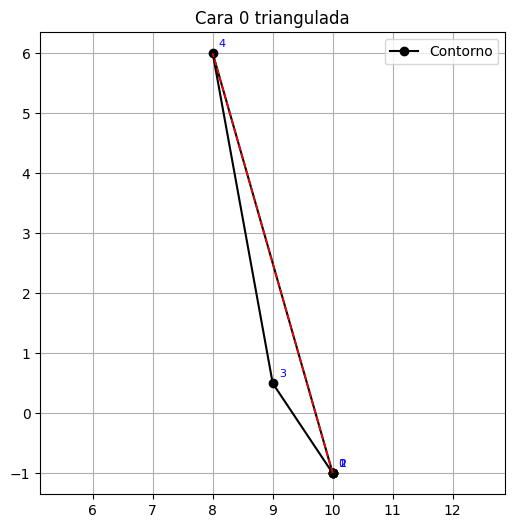

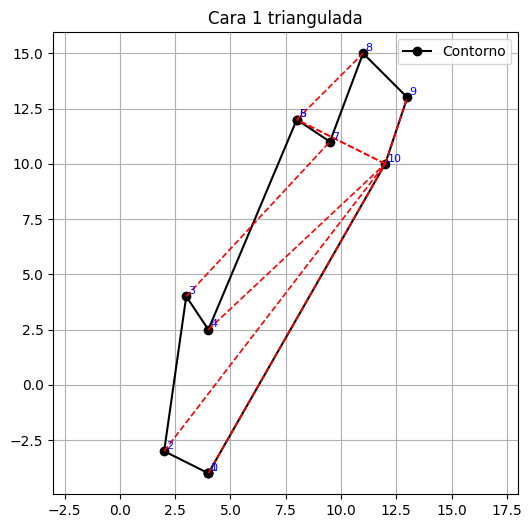

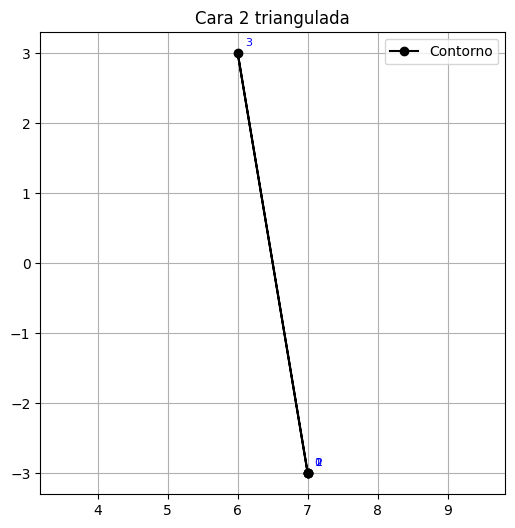

In [40]:
caras_trianguladas = obtener_caras_candidatas(dcel)

for i, cara in enumerate(caras_trianguladas):
    diagonales = triangular_cara_y_monotona(cara)
    visualizar_triangulacion_fallida(cara, diagonales, titulo=f"Cara {i} triangulada")


In [41]:
import matplotlib.pyplot as plt

def visualizar_triangulacion_cara(cara, diagonales, titulo="Cara triangulada"):
    """
    Visualiza la cara dada y las diagonales que la triangulan.
    """
    vertices = obtener_vertices_cara(cara)
    coords = [(v.x, v.y) for v in vertices]
    coords.append(coords[0])  # cerrar el ciclo

    plt.figure(figsize=(6, 6))

    # 1. Contorno original
    x, y = zip(*coords)
    plt.plot(x, y, 'o-k', linewidth=1.5, label="Contorno")

    for i, (vx, vy) in enumerate(coords[:-1]):
        label = f"{i}\n({vx:.1f}, {vy:.1f})"
        plt.text(vx + 0.1, vy + 0.1, label, fontsize=8, color='blue')

    # 2. Diagonales sobre el mismo gráfico
    for v1, v2 in diagonales:
        plt.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', linewidth=1.2)

    plt.title(titulo)
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()


▶️ Visualizando triangulación de cara 0...


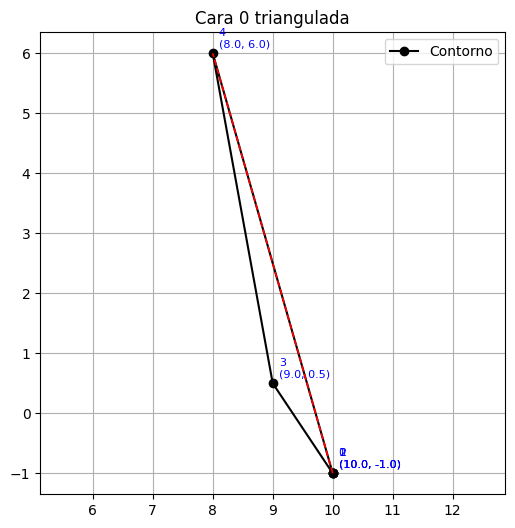

▶️ Visualizando triangulación de cara 1...


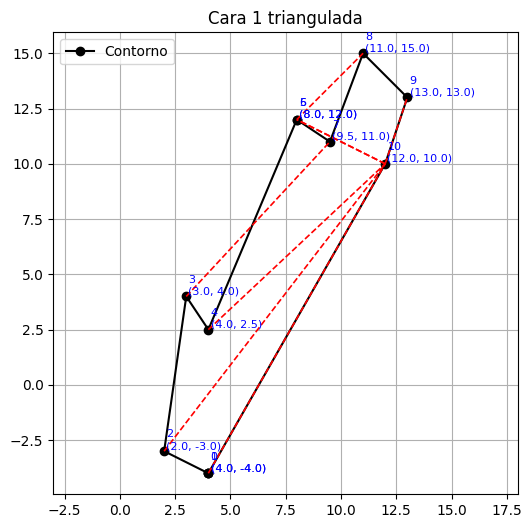

▶️ Visualizando triangulación de cara 2...


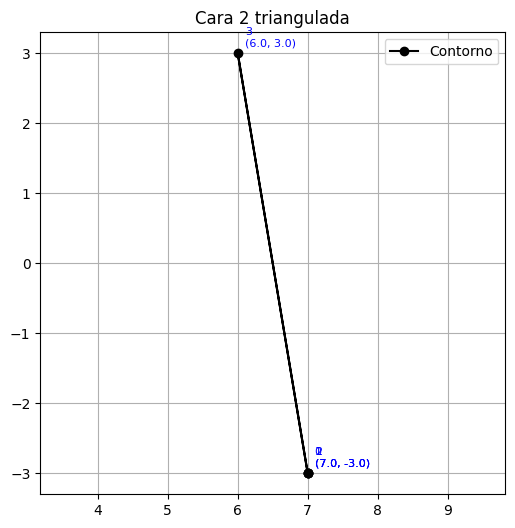

In [42]:
caras_candidatas = obtener_caras_candidatas(dcel)

for i, cara in enumerate(caras_candidatas):
    print(f"▶️ Visualizando triangulación de cara {i}...")
    diagonales = triangular_cara_y_monotona(cara)
    visualizar_triangulacion_cara(cara, diagonales, titulo=f"Cara {i} triangulada")


In [43]:
def insertar_diagonal_y_actualizar_caras(dcel, v1, v2, cara_original):
    """
    Inserta una diagonal entre v1 y v2 dentro de la cara_original,
    actualizando la estructura DCEL para reflejar la creación de dos nuevas caras.
    """
    # Crear las dos nuevas semi-aristas (twins entre sí)
    e1, e2 = dcel.add_edge(v1, v2)

    # Insertar e1 en la secuencia desde v1 a v2
    e1.next, e1.prev = encontrar_next_prev_para_diagonal(v1, v2, cara_original)
    e2.next, e2.prev = encontrar_next_prev_para_diagonal(v2, v1, cara_original)

    # Conectar prev y next adecuadamente
    if e1.next:
        e1.next.prev = e1
    if e1.prev:
        e1.prev.next = e1
    if e2.next:
        e2.next.prev = e2
    if e2.prev:
        e2.prev.next = e2

    # Crear dos nuevas caras
    nueva_cara1 = Face()
    nueva_cara2 = Face()

    # Asignar incident_face recorriendo desde e1 y e2
    recorrer_y_asignar_cara(e1, nueva_cara1)
    recorrer_y_asignar_cara(e2, nueva_cara2)

    # Agregar las nuevas caras al DCEL
    dcel.faces.append(nueva_cara1)
    dcel.faces.append(nueva_cara2)


def encontrar_next_prev_para_diagonal(v_origen, v_destino, cara):
    """
    Dado el vértice de origen y destino de la diagonal, busca dentro de la cara original
    los next y prev correctos donde insertar la nueva arista.
    Retorna (next, prev) desde el punto de vista de v_origen.
    """
    start = cara.outer_component
    edge = start
    while True:
        if edge.origin == v_origen:
            actual = edge
            break
        edge = edge.next
        if edge == start:
            return None, None  # No encontrado

    # Buscar camino hasta v_destino
    forward = actual
    while forward.twin.origin != v_destino:
        forward = forward.next
        if forward == actual:
            break

    # backward = camino inverso
    backward = actual
    while backward.prev.origin != v_destino:
        backward = backward.prev
        if backward == actual:
            break

    return forward, backward


def recorrer_y_asignar_cara(edge_inicio, cara):
    """
    Dado el inicio de un ciclo, recorre las aristas asignando la cara.
    """
    edge = edge_inicio
    while True:
        edge.incident_face = cara
        if cara.outer_component is None:
            cara.outer_component = edge
        edge = edge.next
        if edge == edge_inicio:
            break


In [44]:
# Paso 1: Escoge la cara sobre la que vas a trabajar
caras_candidatas = obtener_caras_candidatas(dcel)
cara = caras_candidatas[1]  # puedes cambiar el índice según el caso

# Paso 2: Escoge dos vértices válidos dentro de esa cara (por inspección visual)
vertices = obtener_vertices_cara(cara)
v1 = vertices[0]
v2 = vertices[4]  # cambia este índice si quieres probar otra

# Paso 3: Insertar la diagonal y actualizar la DCEL
insertar_diagonal_y_actualizar_caras(dcel, v1, v2, cara)

# Paso 4: Verifica la integridad después del cambio
verificar_integridad_dcel(dcel)

# Paso 5: Visualiza el resultado
visualizar_cara_con_diagonales(dcel.faces[-1], diagonales=[(v1, v2)], titulo="Cara nueva tras insertar diagonal")
visualizar_cara_con_diagonales(dcel.faces[-2], diagonales=[(v1, v2)], titulo="Cara original ajustada tras inserción")


KeyboardInterrupt: 

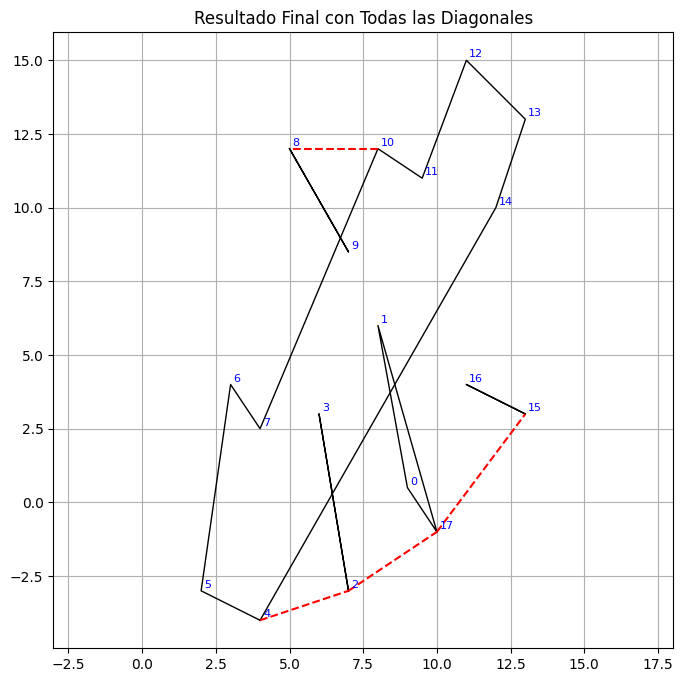

In [68]:
from matplotlib import pyplot as plt

def visualizar_dcel_con_todas_las_diagonales(dcel, diagonales, titulo="Resultado Final con Todas las Diagonales"):
    """
    Visualiza toda la estructura del DCEL mostrando:
    - El contorno del polígono (en negro)
    - Todas las diagonales insertadas (en rojo punteado)
    """
    plt.figure(figsize=(8, 8))
    
    # Dibujar todas las caras con aristas
    for face in dcel.faces:
        if face.outer_component is None:
            continue
        coords = []
        start = edge = face.outer_component
        visitadas = set()
        while edge not in visitadas and edge is not None:
            visitadas.add(edge)
            coords.append((edge.origin.x, edge.origin.y))
            edge = edge.next
            if edge == start:
                break
        coords.append(coords[0])  # cerrar ciclo
        x, y = zip(*coords)
        plt.plot(x, y, 'k-', linewidth=1)

    # Dibujar diagonales en rojo
    for v1, v2 in diagonales:
        plt.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', linewidth=1.5)

    # Etiquetar vértices
    for i, v in enumerate(dcel.vertices):
        plt.text(v.x + 0.1, v.y + 0.1, f"{i}", fontsize=8, color='blue')

    plt.title(titulo)
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Visualizar el resultado final con todas las diagonales insertadas
visualizar_dcel_con_todas_las_diagonales(dcel, diagonales)
